# Correlation

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# TODO: update with real data

# Load survey data
# Rows = respondents, columns = survey questions
df = pd.read_csv("../input/data/ESS8e02_3_self_processed/ess8_cca_initial_beliefs.csv")

In [3]:
# create groups
country_groups = []

# Country
uk_df = df[df["cntry"] == "GB"]
ru_df = df[df["cntry"] == "RU"]

# Age
youth_df = df[(df["agea"] >= 15) & (df["agea"] <= 34)]
print(len(youth_df))
midage_df = df[(df["agea"] >= 35) & (df["agea"] <= 54)]
print(len(midage_df))
senior_df = df[df["agea"] >= 55]
print(len(senior_df))

8877
12884
15274


In [4]:
# Keep only question columns
#X = df.iloc[:, 14:34]
#print(X.columns)

X = uk_df.iloc[:, 14:34]
#X = ru_df.iloc[:, 14:34]

#X = senior_df.iloc[:, 14:34]

In [5]:
# Postprocessing hopefully not necessary (?)

# Make sure answers are numeric
#X = X.apply(pd.to_numeric, errors="coerce")

# Optionally drop respondents with missing answers
#X = X.dropna()

In [6]:
# Compute question-question correlation matrix
corr = X.corr(method="pearson") # TODO: decide method

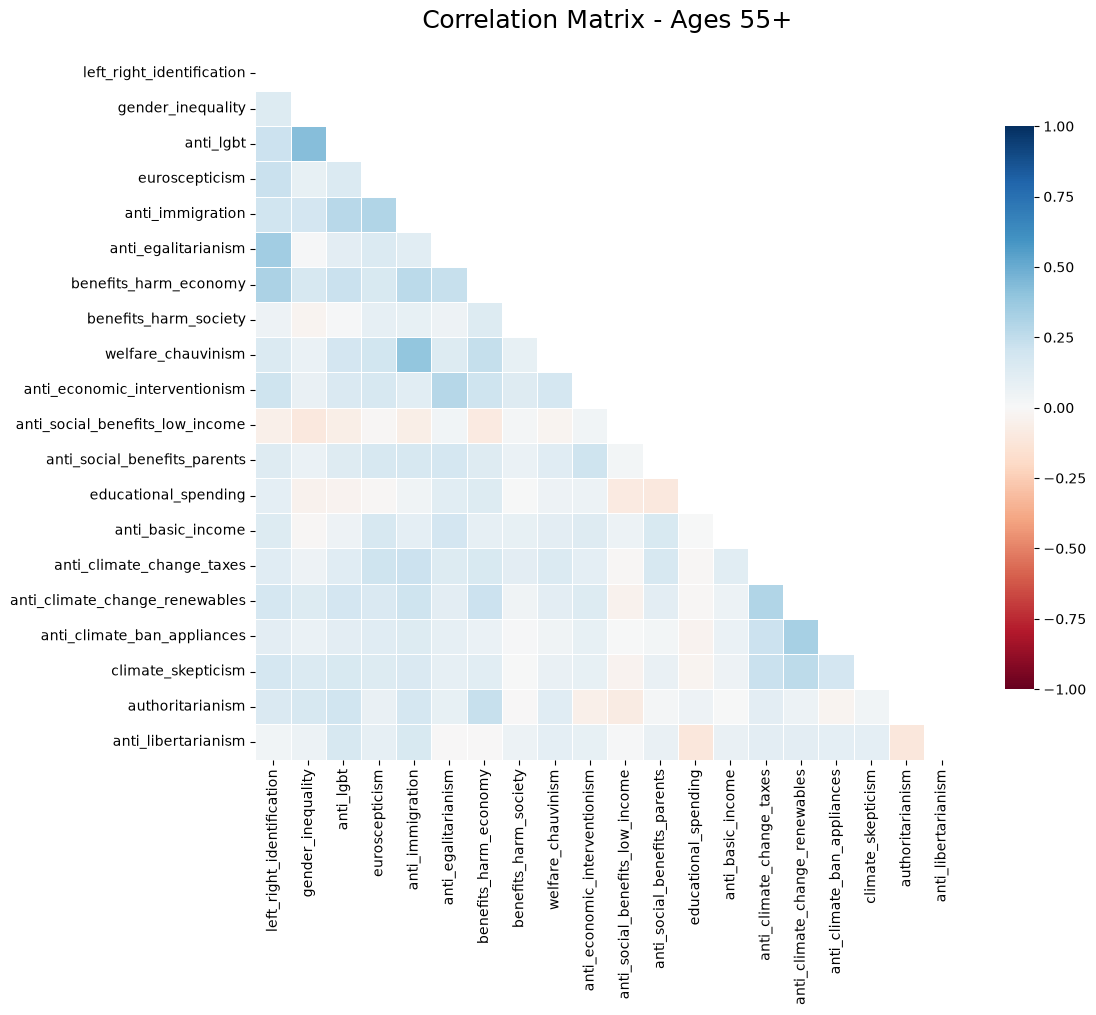

In [7]:
# Show only lower triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "Correlation Matrix - Ages 55+",
    fontsize=18,
    pad=20
)

plt.tight_layout()

plt.savefig(
    "../plots/correlation_matrix_senior.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [8]:
# Thresholding not necessary (?)

# Threshold weak correlations
#threshold = 0.3

adjacency = corr.copy()
#adjacency[np.abs(adjacency) < threshold] = 0
for col in adjacency.columns:
    adjacency.loc[col, col] = 0

In [9]:
# Build network
G = nx.from_pandas_adjacency(adjacency)

# Probably we dont want this (?)
# Remove zero-weight edges
#G.remove_edges_from([
#    (u, v) for u, v, w in G.edges(data="weight")
#    if w == 0
#])

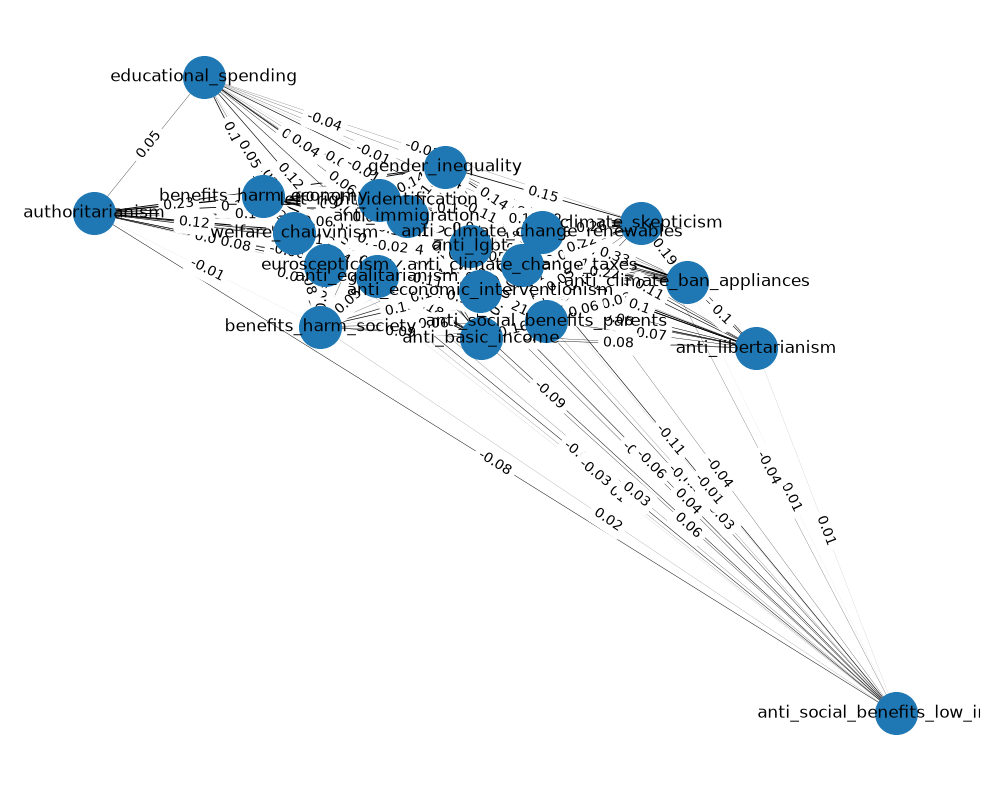

In [10]:
# Draw network
pos = nx.spring_layout(G, seed=42)

edge_weights = [abs(G[u][v]["weight"]) * 4 for u, v in G.edges()]
edge_labels = {
    (u, v): round(G[u][v]["weight"], 2)
    for u, v in G.edges()
}

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_size=900)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, width=edge_weights)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.axis("off")
plt.tight_layout()
plt.show()

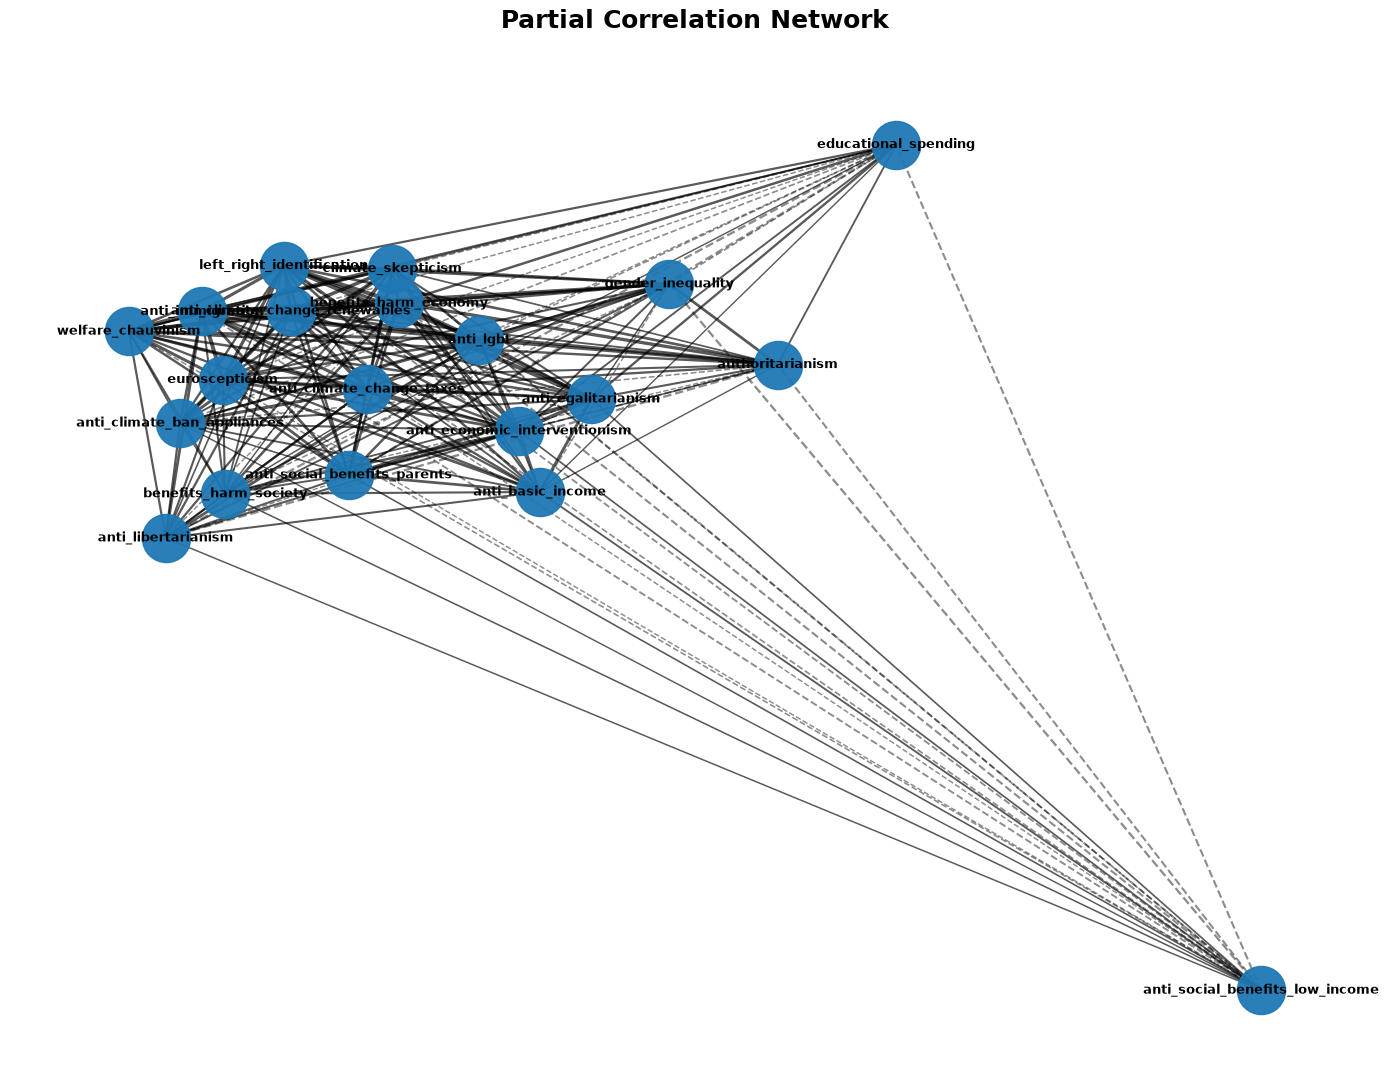

In [11]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Optional: remove isolated nodes for a cleaner figure
G_plot = G.copy()
G_plot.remove_nodes_from(list(nx.isolates(G_plot)))

# Use edge weights
weights = np.array([
    G_plot[u][v]["weight"]
    for u, v in G_plot.edges()
])

# Edge width based on absolute partial correlation
edge_widths = 1 + 6 * np.abs(weights)

# Positive edges solid, negative edges dashed
positive_edges = [
    (u, v) for u, v in G_plot.edges()
    if G_plot[u][v]["weight"] > 0
]

negative_edges = [
    (u, v) for u, v in G_plot.edges()
    if G_plot[u][v]["weight"] < 0
]

# Layout
pos = nx.spring_layout(
    G_plot,
    seed=42,
    k=1.2,
    iterations=200,
    weight="weight"
)

plt.figure(figsize=(14, 11))

# Draw nodes
nx.draw_networkx_nodes(
    G_plot,
    pos,
    node_size=1200,
    alpha=0.95
)

# Draw positive edges
nx.draw_networkx_edges(
    G_plot,
    pos,
    edgelist=positive_edges,
    width=[
        1 + 6 * abs(G_plot[u][v]["weight"])
        for u, v in positive_edges
    ],
    alpha=0.65
)

# Draw negative edges
nx.draw_networkx_edges(
    G_plot,
    pos,
    edgelist=negative_edges,
    width=[
        1 + 6 * abs(G_plot[u][v]["weight"])
        for u, v in negative_edges
    ],
    alpha=0.45,
    style="dashed"
)

# Draw labels
nx.draw_networkx_labels(
    G_plot,
    pos,
    font_size=9,
    font_weight="bold"
)

plt.title(
    "Partial Correlation Network",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.axis("off")
plt.tight_layout()
plt.show()

# Partial Correlation

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV

In [13]:
# TODO: fix later Nan

# Drop respondents with any missing values
X = X.dropna()

# Standardize variables so that each question has mean 0 and variance 1.
# Graphical Lasso assumes variables are on comparable scales.
X_scaled = StandardScaler().fit_transform(X)

In [14]:
# Estimate a sparse inverse covariance (precision) matrix.
# The CV version automatically chooses the regularization parameter.
model = GraphicalLassoCV()
model.fit(X_scaled)

# Precision matrix (inverse covariance matrix).
# Zeros indicate conditional independence.
precision = model.precision_

# Convert precision matrix to partial correlations.
#
# rho_ij = -Theta_ij /
#          sqrt(Theta_ii * Theta_jj)
#
# where Theta is the precision matrix.
partial_corr = -precision / np.sqrt(
    np.outer(
        np.diag(precision),
        np.diag(precision)
    )
)

# Remove self-correlations.
np.fill_diagonal(partial_corr, 0)

/home/irina/anaconda3/envs/complexity72-simpol/lib/python3.12/site-packages/sklearn/covariance/_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 100 iteration: dual gap: -9.641e-04
  warnings.warn(


In [15]:
# Convert back to a DataFrame for easier indexing and plotting.
partial_corr = pd.DataFrame(
    partial_corr,
    index=X.columns,
    columns=X.columns
)

# Skip thresholding (?)

# Remove very weak associations.
# Larger thresholds produce sparser networks.
#threshold = 0.05

adjacency = partial_corr.copy()
#adjacency[np.abs(adjacency) < threshold] = 0

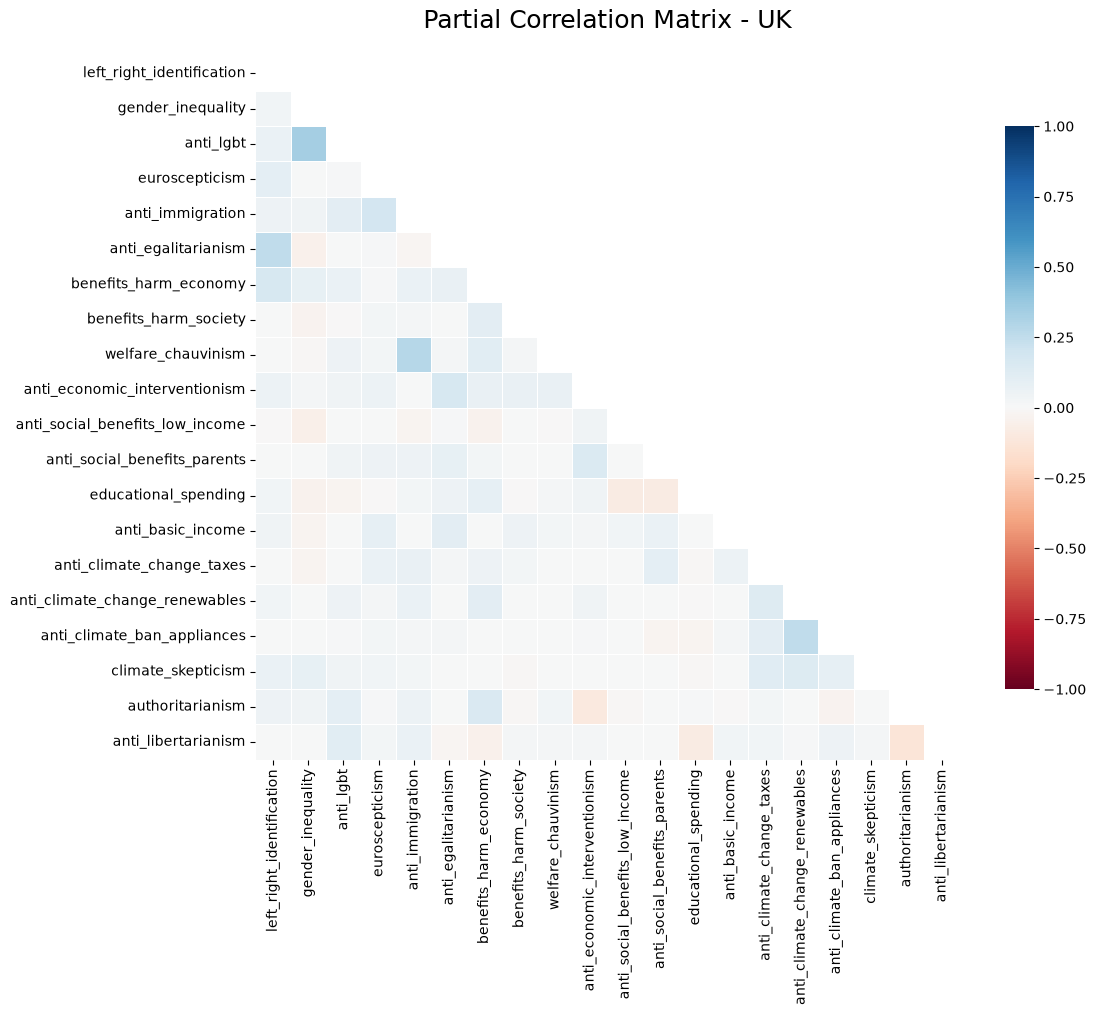

In [16]:
# Show only lower triangle
mask = np.triu(np.ones_like(partial_corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    partial_corr,
    mask=mask,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "Partial Correlation Matrix - UK",
    fontsize=18,
    pad=20
)

plt.tight_layout()

plt.savefig(
    "../plots/partial_correlation_matrix_uk.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [17]:
# Create a NetworkX graph.
# Nodes = questions
# Edge weights = partial correlations.
G_partial = nx.from_pandas_adjacency(adjacency)

# Should I (?)
# Remove edges whose weight is exactly zero.
#G_partial.remove_edges_from([
#    (u, v)
#    for u, v, w in G_partial.edges(data="weight")
#    if w == 0
#])

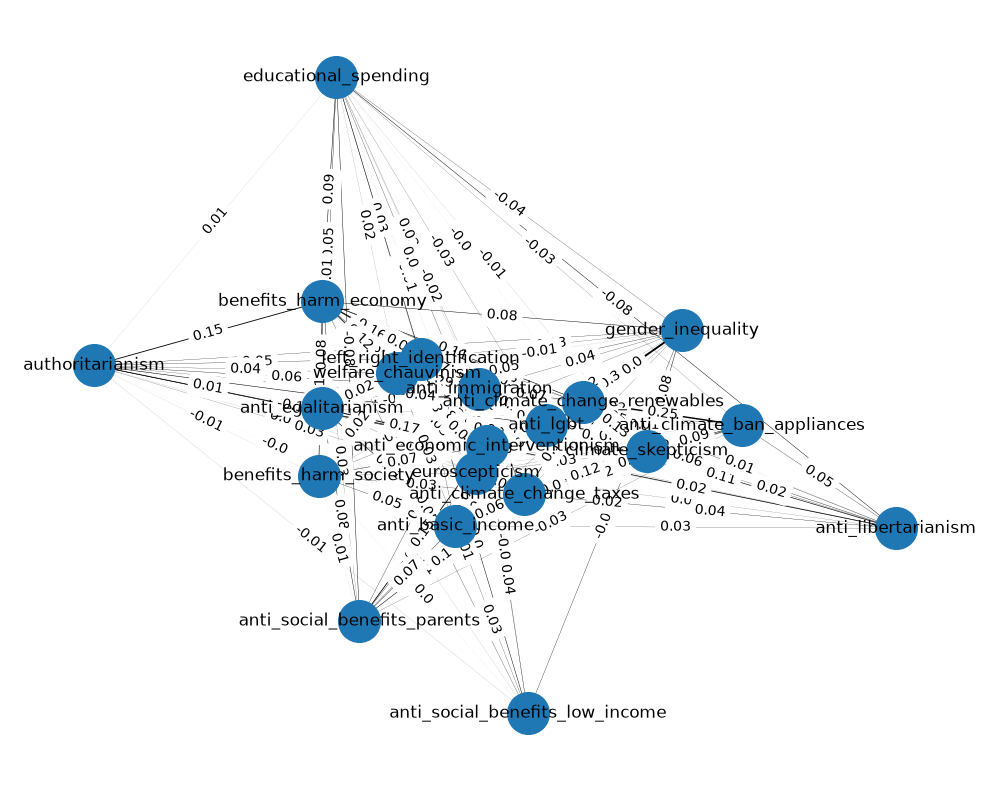

In [18]:
# Draw network
pos = nx.spring_layout(G_partial, seed=42)

edge_weights = [abs(G_partial[u][v]["weight"]) * 4 for u, v in G_partial.edges()]
edge_labels = {
    (u, v): round(G_partial[u][v]["weight"], 2)
    for u, v in G_partial.edges()
}

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G_partial, pos, node_size=900)
nx.draw_networkx_labels(G_partial, pos)
nx.draw_networkx_edges(G_partial, pos, width=edge_weights)
nx.draw_networkx_edge_labels(G_partial, pos, edge_labels=edge_labels)

plt.axis("off")
plt.tight_layout()
plt.show()

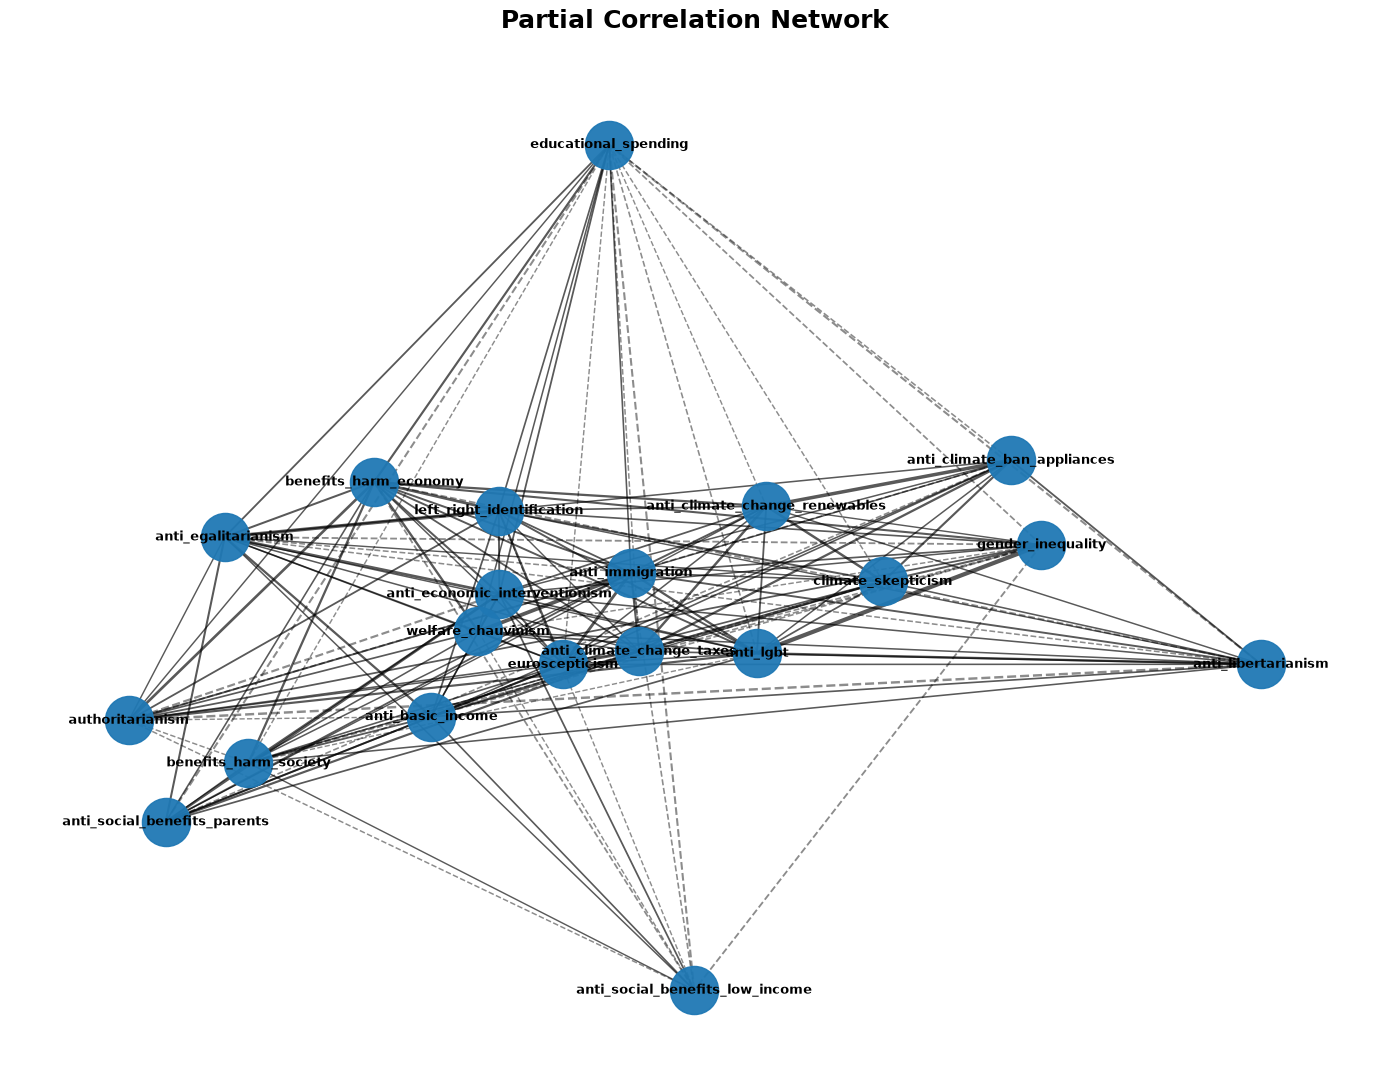

In [19]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Optional: remove isolated nodes for a cleaner figure
G_plot = G_partial.copy()
G_plot.remove_nodes_from(list(nx.isolates(G_plot)))

# Use edge weights
weights = np.array([
    G_plot[u][v]["weight"]
    for u, v in G_plot.edges()
])

# Edge width based on absolute partial correlation
edge_widths = 1 + 6 * np.abs(weights)

# Positive edges solid, negative edges dashed
positive_edges = [
    (u, v) for u, v in G_plot.edges()
    if G_plot[u][v]["weight"] > 0
]

negative_edges = [
    (u, v) for u, v in G_plot.edges()
    if G_plot[u][v]["weight"] < 0
]

# Layout
pos = nx.spring_layout(
    G_plot,
    seed=42,
    k=1.2,
    iterations=200,
    weight="weight"
)

plt.figure(figsize=(14, 11))

# Draw nodes
nx.draw_networkx_nodes(
    G_plot,
    pos,
    node_size=1200,
    alpha=0.95
)

# Draw positive edges
nx.draw_networkx_edges(
    G_plot,
    pos,
    edgelist=positive_edges,
    width=[
        1 + 6 * abs(G_plot[u][v]["weight"])
        for u, v in positive_edges
    ],
    alpha=0.65
)

# Draw negative edges
nx.draw_networkx_edges(
    G_plot,
    pos,
    edgelist=negative_edges,
    width=[
        1 + 6 * abs(G_plot[u][v]["weight"])
        for u, v in negative_edges
    ],
    alpha=0.45,
    style="dashed"
)

# Draw labels
nx.draw_networkx_labels(
    G_plot,
    pos,
    font_size=9,
    font_weight="bold"
)

plt.title(
    "Partial Correlation Network",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.axis("off")
plt.tight_layout()
plt.show()